In [1]:
# Install Libraries
!pip install matplotlib numpy

In [2]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import json

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [3]:
# Create Warehouse Grid
warehouse = np.zeros((15,15))

print(warehouse)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [4]:
# Add Robot
robot = (0,0)

warehouse[robot] = 1

In [5]:
# Add Obstacles (Shelves = 2)
warehouse[3:6,4] = 2
warehouse[8:11,8] = 2
warehouse[6:9,12] = 2
warehouse[10,2:5] = 2

In [6]:
# Add Box (3)
box = (5,10)

warehouse[box] = 3

In [7]:
# Add Target(4)
target = (13,13)

warehouse[target] = 4

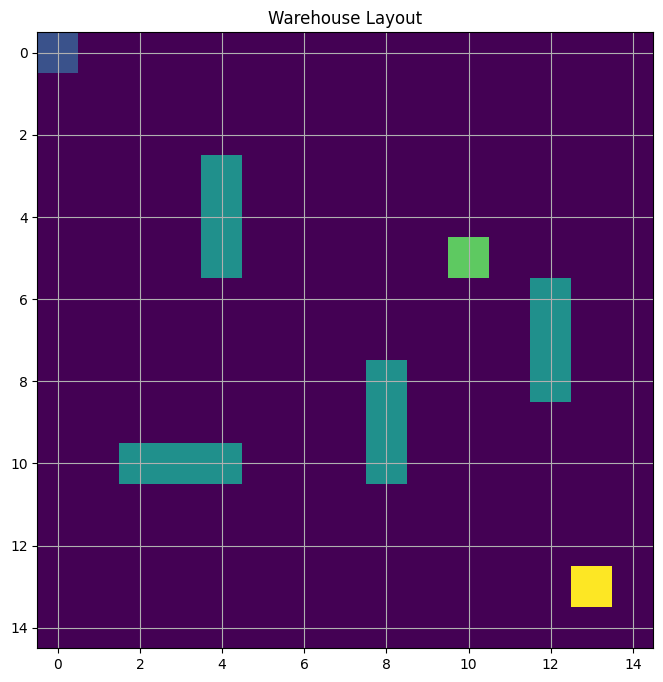

In [8]:
# Visualize Warehouse

plt.figure(figsize=(8,8))

plt.imshow(warehouse, cmap="viridis")

plt.title("Warehouse Layout")

plt.grid()

plt.show()

In [9]:
# Print Positions
print("Robot Position :", robot)

print("Box Position :", box)

print("Target Position :", target)

Robot Position : (0, 0)
Box Position : (5, 10)
Target Position : (13, 13)


In [10]:
# Calculate Path to Box
path_to_box = []

r, c = robot

# Move vertically
while r < box[0]:
    r += 1
    path_to_box.append((r, c))

# Move horizontally
while c < box[1]:
    c += 1
    path_to_box.append((r, c))

print("Steps to Box:", len(path_to_box))
print(path_to_box)

Steps to Box: 15
[(1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10)]


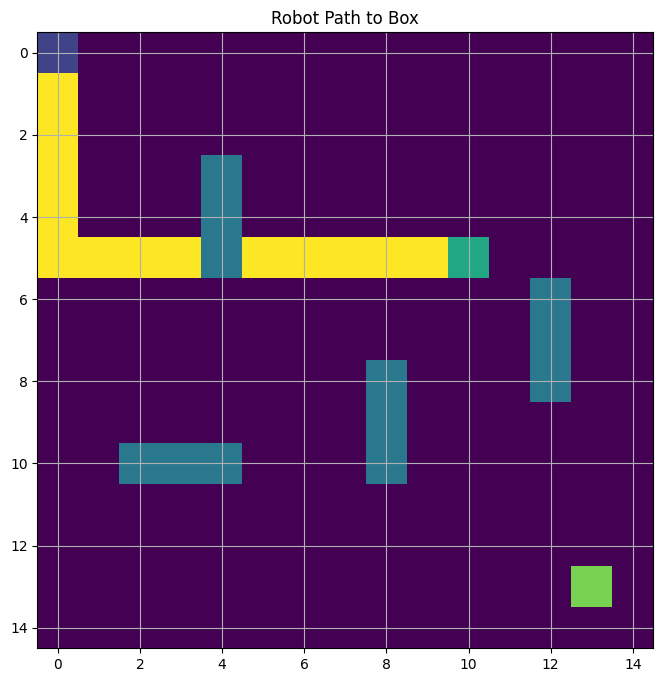

In [11]:
# Visualize Robot Path
path_grid = warehouse.copy()

for cell in path_to_box:
    if path_grid[cell] == 0:
        path_grid[cell] = 5

plt.figure(figsize=(8,8))

plt.imshow(path_grid, cmap="viridis")

plt.title("Robot Path to Box")

plt.grid()

plt.show()

In [12]:
# Pick the Box
# Robot picks the box

print("="*40)
print("🤖 Robot reached the box.")
print("📦 Box picked successfully!")
print("="*40)

box_picked = True

🤖 Robot reached the box.
📦 Box picked successfully!


In [13]:
#Calculate Path from Box to Target
path_to_target = []

r, c = box

# Move vertically
while r < target[0]:
    r += 1
    path_to_target.append((r, c))

# Move horizontally
while c < target[1]:
    c += 1
    path_to_target.append((r, c))

print("Steps to Target:", len(path_to_target))

Steps to Target: 11


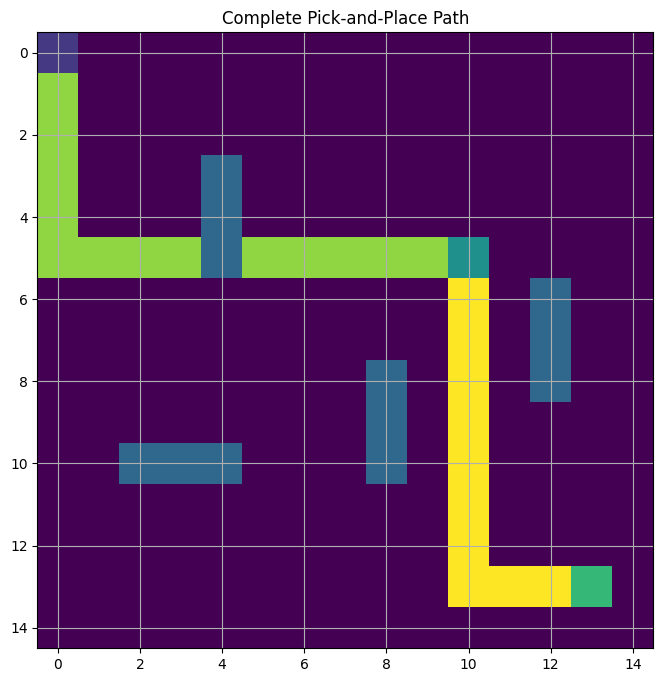

In [14]:
# Draw Complete Robot Path
final_grid = warehouse.copy()

# Path to box
for cell in path_to_box:
    if final_grid[cell] == 0:
        final_grid[cell] = 5

# Path to target
for cell in path_to_target:
    if final_grid[cell] == 0:
        final_grid[cell] = 6

plt.figure(figsize=(8,8))

plt.imshow(final_grid, cmap="viridis")

plt.title("Complete Pick-and-Place Path")

plt.grid()

plt.show()

In [15]:
# Place the Box
print("="*40)
print("📦 Box delivered successfully!")
print("🎯 Target reached.")
print("="*40)

box_delivered = True

📦 Box delivered successfully!
🎯 Target reached.


In [16]:
# Save Final Image
plt.imsave("warehouse_result.png", final_grid)

print("✅ Warehouse image saved.")

✅ Warehouse image saved.


In [17]:
#Export JSON
report = {
    "robot": "Robot-01",
    "box_picked": box_picked,
    "box_delivered": box_delivered,
    "target_reached": True,
    "steps_to_box": len(path_to_box),
    "steps_to_target": len(path_to_target),
    "total_steps": len(path_to_box) + len(path_to_target),
    "status": "Success"
}

with open("task_report.json", "w") as f:
    json.dump(report, f, indent=4)

print("✅ JSON Report Saved")

✅ JSON Report Saved


In [18]:
#Generate Professional Report
print("="*45)
print("      WAREHOUSE PICK-AND-PLACE REPORT")
print("="*45)

print(f"Robot ID         : Robot-01")
print(f"Box Picked       : {'Yes' if box_picked else 'No'}")
print(f"Box Delivered    : {'Yes' if box_delivered else 'No'}")
print(f"Steps to Box     : {len(path_to_box)}")
print(f"Steps to Target  : {len(path_to_target)}")
print(f"Total Steps      : {len(path_to_box) + len(path_to_target)}")
print("Mission Status   : SUCCESS")

print("="*45)

      WAREHOUSE PICK-AND-PLACE REPORT
Robot ID         : Robot-01
Box Picked       : Yes
Box Delivered    : Yes
Steps to Box     : 15
Steps to Target  : 11
Total Steps      : 26
Mission Status   : SUCCESS


In [19]:
# Download Outputs
from google.colab import files

files.download("warehouse_result.png")
files.download("task_report.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Improvement- 1 : A* alogorithm to find the shortest collision-free path
#Import Priority Queue

from queue import PriorityQueue

In [21]:
# A* Algorithm
def astar(grid, start, goal):

    rows, cols = grid.shape

    open_set = PriorityQueue()

    open_set.put((0, start))

    came_from = {}

    g_score = {start: 0}

    def heuristic(a, b):
        return abs(a[0]-b[0]) + abs(a[1]-b[1])

    while not open_set.empty():

        current = open_set.get()[1]

        if current == goal:

            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.reverse()

            return path

        r, c = current

        neighbors = [

            (r+1,c),

            (r-1,c),

            (r,c+1),

            (r,c-1)

        ]

        for nr, nc in neighbors:

            if 0 <= nr < rows and 0 <= nc < cols:

                if grid[nr,nc] == 2:
                    continue

                tentative = g_score[current] + 1

                if (nr,nc) not in g_score or tentative < g_score[(nr,nc)]:

                    g_score[(nr,nc)] = tentative

                    priority = tentative + heuristic((nr,nc), goal)

                    open_set.put((priority,(nr,nc)))

                    came_from[(nr,nc)] = current

    return []

In [22]:
#Find Path to Box
path_to_box = astar(warehouse, robot, box)

print(path_to_box)

print("Steps:", len(path_to_box))

[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (1, 10), (2, 10), (3, 10), (4, 10), (5, 10)]
Steps: 15


In [23]:
#Path to Target
path_to_target = astar(warehouse, box, target)

print(path_to_target)

print("Steps:", len(path_to_target))

[(5, 11), (5, 12), (5, 13), (6, 13), (7, 13), (8, 13), (9, 13), (10, 13), (11, 13), (12, 13), (13, 13)]
Steps: 11


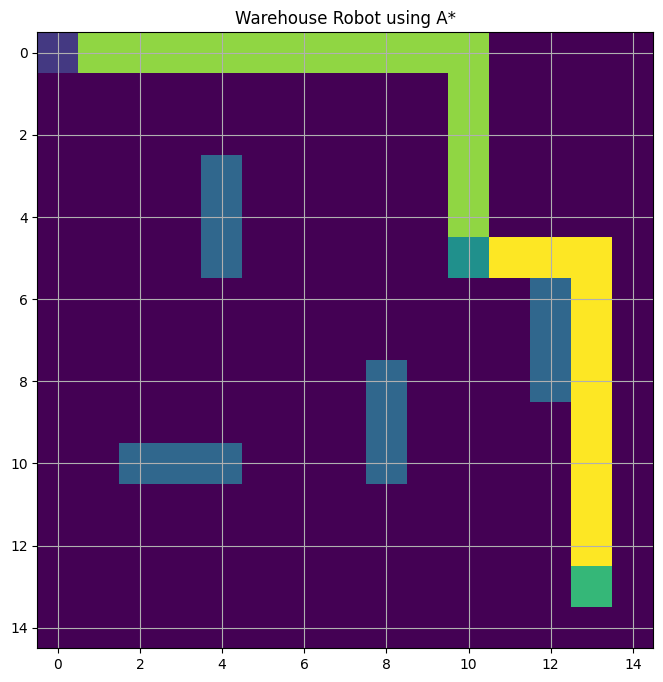

In [24]:
# Visualize
grid = warehouse.copy()

for p in path_to_box:

    if grid[p] == 0:
        grid[p] = 5

for p in path_to_target:

    if grid[p] == 0:
        grid[p] = 6

plt.figure(figsize=(8,8))

plt.imshow(grid,cmap="viridis")

plt.title("Warehouse Robot using A*")

plt.grid()

plt.show()

In [25]:
#Report
print("="*45)
print("WAREHOUSE PICK & PLACE REPORT")
print("="*45)

print("Navigation Algorithm : A* Search")
print(f"Steps to Box        : {len(path_to_box)}")
print(f"Steps to Target     : {len(path_to_target)}")
print(f"Total Distance      : {len(path_to_box)+len(path_to_target)}")
print("Collision Free      : Yes")
print("Mission Status      : SUCCESS")

print("="*45)

WAREHOUSE PICK & PLACE REPORT
Navigation Algorithm : A* Search
Steps to Box        : 15
Steps to Target     : 11
Total Distance      : 26
Collision Free      : Yes
Mission Status      : SUCCESS


In [26]:
#Update JSON
report = {

    "algorithm":"A*",

    "collision_free":True,

    "box_picked":True,

    "box_delivered":True,

    "steps":len(path_to_box)+len(path_to_target),

    "status":"Success"

}

with open("task_report.json","w") as f:
    json.dump(report,f,indent=4)

In [31]:
# Improvement 2: Animated Robot Movement (A* Version)
#Import Required Libraries
from IPython.display import clear_output
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import time

In [32]:
#Combine Both Paths
# Complete robot path

complete_path = path_to_box + path_to_target

print("Total Steps:", len(complete_path))

Total Steps: 26


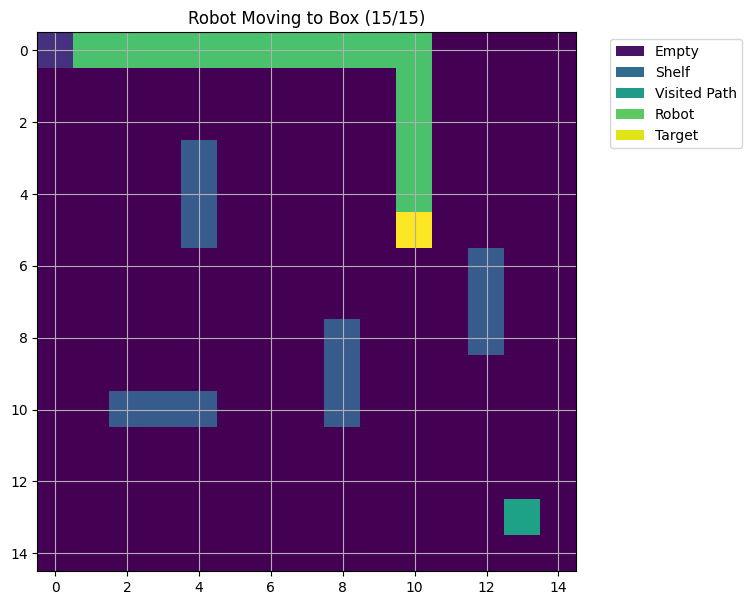

📦 Box Picked Successfully!


In [33]:
# Animate Robot Moving to the Box
# Animation: Robot moving to the box

# Animate robot moving to the box

animation_grid = warehouse.copy()

for step, position in enumerate(path_to_box):

    clear_output(wait=True)

    display_grid = animation_grid.copy()

    # Show visited path
    for visited in path_to_box[:step]:
        if display_grid[visited] == 0:
            display_grid[visited] = 5

    # Current robot position
    display_grid[position] = 7

    plt.figure(figsize=(7,7))

    plt.imshow(display_grid, cmap="viridis")

    plt.title(f"Robot Moving to Box ({step+1}/{len(path_to_box)})")

    plt.grid(True)

    legend_elements = [
        Patch(facecolor=plt.cm.viridis(0.05), label='Empty'),
        Patch(facecolor=plt.cm.viridis(0.35), label='Shelf'),
        Patch(facecolor=plt.cm.viridis(0.55), label='Visited Path'),
        Patch(facecolor=plt.cm.viridis(0.75), label='Robot'),
        Patch(facecolor=plt.cm.viridis(0.95), label='Target')
    ]

    plt.legend(handles=legend_elements,
               bbox_to_anchor=(1.05,1),
               loc="upper left")

    plt.show()

    time.sleep(0.3)

print("📦 Box Picked Successfully!")

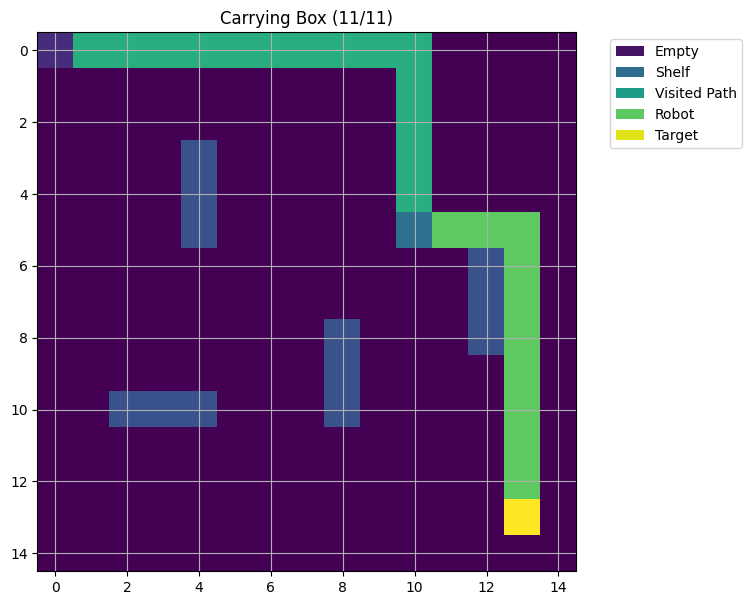

🎯 Box Delivered Successfully!


In [34]:
# Animate Robot Carrying the Box
# Animation: Robot carrying the box

for step, position in enumerate(path_to_target):

    clear_output(wait=True)

    display_grid = animation_grid.copy()

    # Show first path
    for visited in path_to_box:
        if display_grid[visited] == 0:
            display_grid[visited] = 5

    # Show delivery path
    for visited in path_to_target[:step]:
        if display_grid[visited] == 0:
            display_grid[visited] = 6

    # Robot carrying box
    display_grid[position] = 8

    plt.figure(figsize=(7,7))

    plt.imshow(display_grid, cmap="viridis")

    plt.title(f"Carrying Box ({step+1}/{len(path_to_target)})")

    plt.grid(True)

    legend_elements = [
        Patch(facecolor=plt.cm.viridis(0.05), label='Empty'),
        Patch(facecolor=plt.cm.viridis(0.35), label='Shelf'),
        Patch(facecolor=plt.cm.viridis(0.55), label='Visited Path'),
        Patch(facecolor=plt.cm.viridis(0.75), label='Robot'),
        Patch(facecolor=plt.cm.viridis(0.95), label='Target')
    ]

    plt.legend(handles=legend_elements,
               bbox_to_anchor=(1.05,1),
               loc="upper left")

    plt.show()

    time.sleep(0.3)

print("🎯 Box Delivered Successfully!")

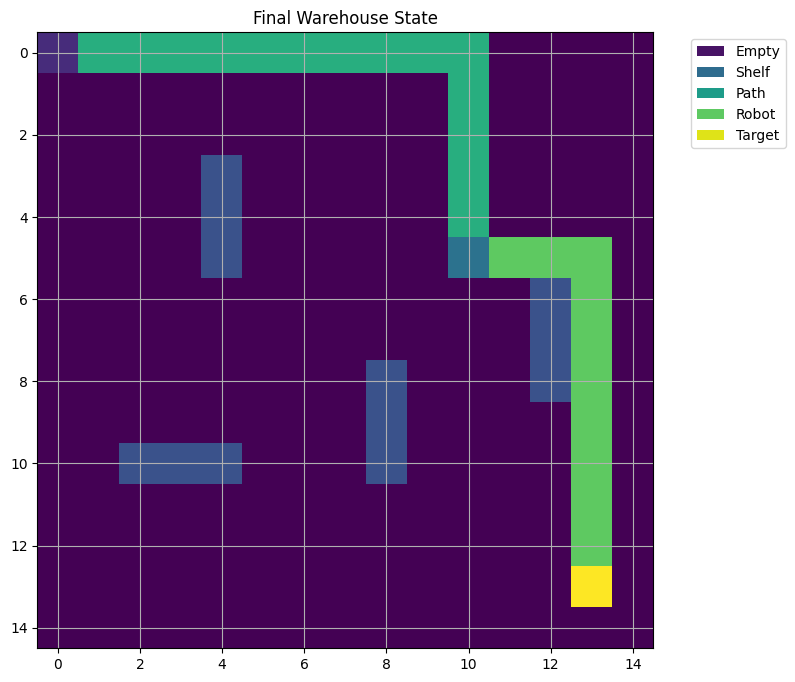

In [35]:
#Final Warehouse State
final_grid = warehouse.copy()

# Show path to box
for cell in path_to_box:
    if final_grid[cell] == 0:
        final_grid[cell] = 5

# Show path to target
for cell in path_to_target:
    if final_grid[cell] == 0:
        final_grid[cell] = 6

# Robot at target
final_grid[target] = 8

plt.figure(figsize=(8,8))

plt.imshow(final_grid, cmap="viridis")

plt.title("Final Warehouse State")

plt.grid(True)

legend_elements = [
    Patch(facecolor=plt.cm.viridis(0.05), label='Empty'),
    Patch(facecolor=plt.cm.viridis(0.35), label='Shelf'),
    Patch(facecolor=plt.cm.viridis(0.55), label='Path'),
    Patch(facecolor=plt.cm.viridis(0.75), label='Robot'),
    Patch(facecolor=plt.cm.viridis(0.95), label='Target')
]

plt.legend(handles=legend_elements,
           bbox_to_anchor=(1.05,1),
           loc="upper left")

plt.show()

In [36]:
#Save Final Image
plt.imsave("warehouse_result.png", final_grid)

print("✅ Final warehouse image saved.")

✅ Final warehouse image saved.
